# Week 9 Phase 1.8 — Model-vs-query-path decomposition

This compact notebook reads the generated artifacts. It does not rerun the experiment.

## 1. Question

Was the Phase 1.7 gain caused mainly by the physics-informed predictor, by the different sequence it queried, or by their interaction?

In [1]:
from pathlib import Path
import json, pandas as pd
ROOT=Path.cwd().parents[1] if Path.cwd().name=='week_09' else Path.cwd()
OUT=ROOT/'outputs'/'week9_phase1_8_model_path_decomposition'
gate=json.loads((OUT/'baseline_gate.json').read_text())
audit=json.loads((OUT/'path_audit.json').read_text())
gate, audit

({'Y00_Y01_budget16_max_accuracy_error': 1.1102230246251565e-16,
  'Y00_budget16_q20_accuracy': 0.7317647058823529,
  'Y00_checkpoint_refit_max_accuracy_error': 1.1102230246251565e-16,
  'Y00_checkpoint_refit_max_error_all_metrics': 1.1102230246251565e-16,
  'Y00_q20_AULC': 0.8135202205882353,
  'Y10_Y11_budget16_max_accuracy_error': 1.1102230246251565e-16,
  'Y11_budget16_q20_accuracy': 0.7847058823529411,
  'Y11_q20_AULC': 0.8335386029411765,
  'budget16_same_model_max_error_all_metrics': 1.1102230246251565e-16,
  'initial_design_exact_matches': 100,
  'keyholes': 73,
  'outer_runs': 100,
  'population_rows': 405,
  'status': 'PASS'},
 {'A0_source': 'outputs/week8_5_frozen_confirmation/week8_5_checkpoint_bundle.tar.gz: checkpoints/*__binary_margin__c01.json, queried_indices[:80]',
  'A0_source_sha256': '1004fc299e00db6f1b2b89e4407f5ac8b2c4815d1169bcaad43dacdebacf72a9',
  'A1_source': 'outputs/week9_phase1_7_physics_ridge_residual_gp/tables/active_information_flow.csv.gz plus frozen i

## 2. Frozen gate and query-path audit

A0 comes from the Week 8.5 canonical Margin checkpoint bundle. A1 comes from the published Phase 1.7 information-flow table. Both contain the same frozen 16-point prefix.

In [2]:
four=pd.read_csv(OUT/'four_way_AULC_summary.csv')
four[four.endpoint=='B1_q20_accuracy_AULC_16_80'][['arm','label','mean_AULC','ci_lower','ci_upper']]

,arm,label,mean_AULC,ci_lower,ci_upper
0,Y00,4D model / 4D path,0.813520,0.806875,0.820317
2,Y01,4D model / physics path,0.807187,0.795960,0.817349
4,Y10,physics model / 4D path,0.829972,0.826443,0.833277
6,Y11,physics model / physics path,0.833539,0.830464,0.836714


## 3. Exact 2 × 2 design

Y00 and Y11 are reused published arms. Y10 and Y01 are the two new counterfactual fixed-path evaluations. At each budget only the path prefix is revealed.

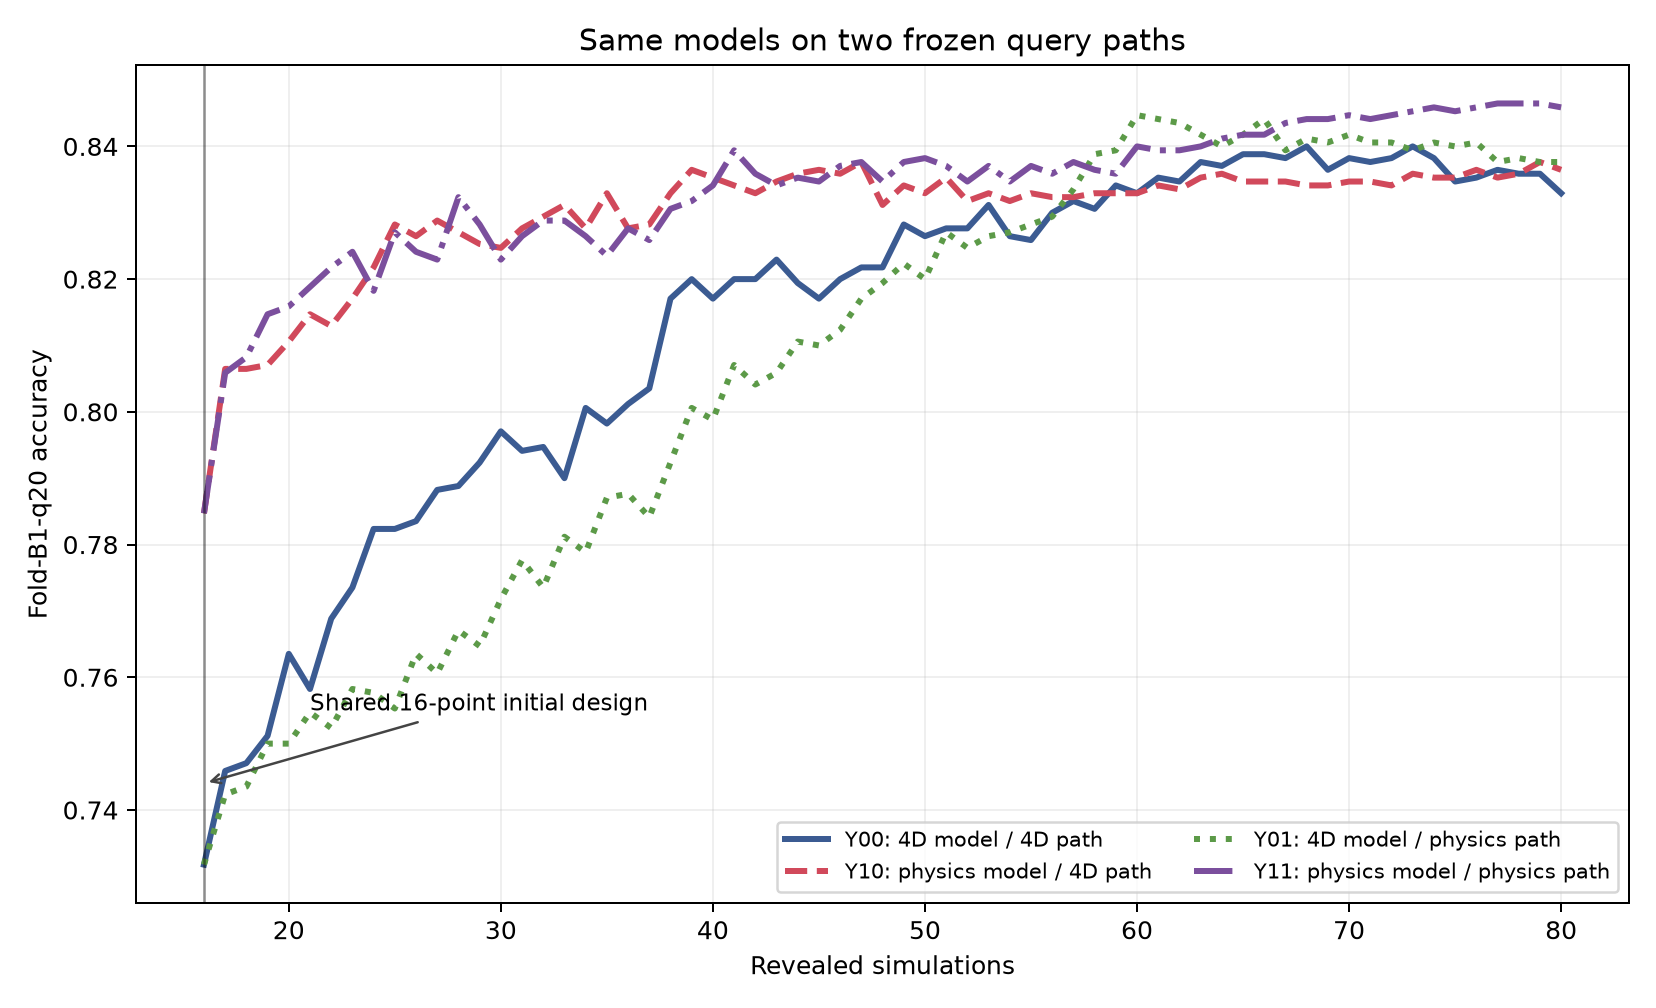

In [3]:
from IPython.display import Image, display
display(Image(filename=str(OUT/'figures'/'01_four_way_q20_learning_curves.png')))

## 4. Model-vs-path decomposition

The symmetric decomposition averages the two possible orders of changing model and path. MODEL + PATH equals Y11 − Y00 for every outer run.

In [4]:
dec=pd.read_csv(OUT/'primary_decomposition.csv')
dec[['effect','mean','ci_lower','ci_upper','decision']]

,effect,mean,ci_lower,ci_upper,decision
0,TOTAL,0.020018,0.014205,0.026351,MODEL_DOMINANT
1,MODEL,0.021402,0.014550,0.028858,MODEL_DOMINANT
2,PATH,-0.001383,-0.005340,0.002606,MODEL_DOMINANT
3,ME_A0,0.016452,0.010859,0.022091,MODEL_DOMINANT
4,ME_A1,0.026351,0.016208,0.037518,MODEL_DOMINANT
5,PE_M0,-0.006333,-0.014049,0.001439,MODEL_DOMINANT
6,PE_M1,0.003566,-0.000230,0.007280,MODEL_DOMINANT
7,INT,0.009899,0.000813,0.019224,MODEL_DOMINANT
8,MODEL_minus_PATH,0.022785,0.013244,0.032978,MODEL_DOMINANT


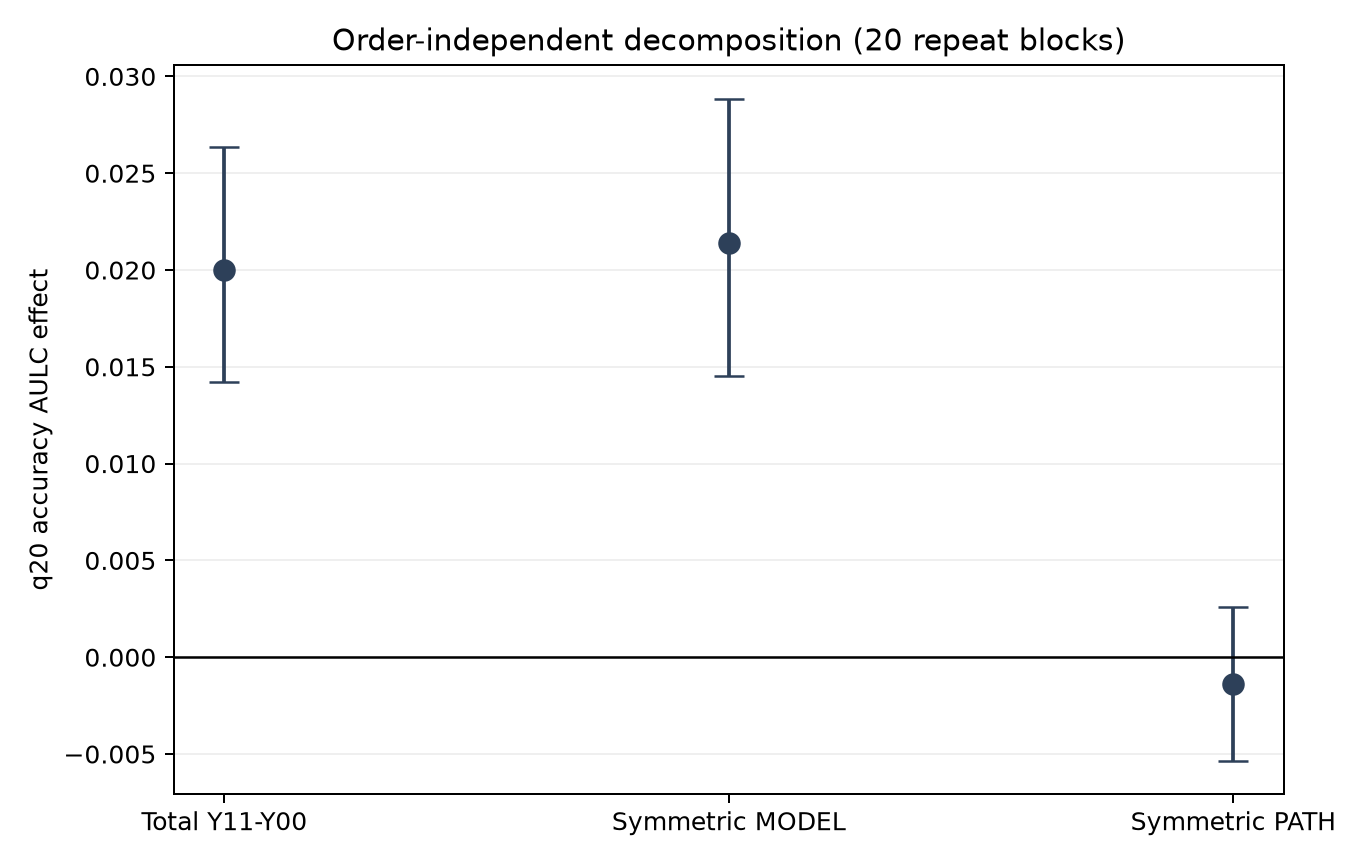

In [5]:
display(Image(filename=str(OUT/'figures'/'02_AULC_decomposition.png')))

## 5. Budget-16 low-data diagnostic

Because the paths are identical at budget 16, any M1−M0 difference is purely a prediction-model effect.

In [6]:
c=pd.read_csv(OUT/'budget_checkpoint_contrasts.csv')
c[(c.budget==16)&(c.effect=='ME_A0')&c.subset.isin(['full81','B1_q30','B1_q20'])&c.metric.isin(['accuracy','balanced_accuracy','keyhole_recall'])]

,effect,budget,subset,metric,mean,ci_lower,ci_upper
108,ME_A0,16,B1_q20,accuracy,0.052941,0.028235,0.078824
109,ME_A0,16,B1_q20,balanced_accuracy,0.084467,0.058419,0.110582
113,ME_A0,16,B1_q20,keyhole_recall,0.224611,0.181880,0.267620
114,ME_A0,16,B1_q30,accuracy,0.042400,0.022400,0.063200
115,ME_A0,16,B1_q30,balanced_accuracy,0.091210,0.068205,0.116119
119,ME_A0,16,B1_q30,keyhole_recall,0.227283,0.187634,0.269094
120,ME_A0,16,full81,accuracy,0.013333,0.005802,0.020991
121,ME_A0,16,full81,balanced_accuracy,0.062926,0.048502,0.078024
125,ME_A0,16,full81,keyhole_recall,0.140286,0.114762,0.167239


## 6. Budget 40/80 classwise interpretation

In [7]:
s=pd.read_csv(OUT/'budget_checkpoint_summary.csv')
s[(s.budget.isin([40,80]))&(s.subset=='B1_q20')&s.metric.isin(['accuracy','balanced_accuracy','keyhole_recall','false_negative','false_positive'])]

,arm,model,path,budget,subset,metric,value
54,Y00,M0,A0,40,B1_q20,accuracy,0.817059
55,Y00,M0,A0,40,B1_q20,balanced_accuracy,0.797113
57,Y00,M0,A0,40,B1_q20,false_negative,1.910000
58,Y00,M0,A0,40,B1_q20,false_positive,1.200000
59,Y00,M0,A0,40,B1_q20,keyhole_recall,0.711044
90,Y00,M0,A0,80,B1_q20,accuracy,0.832941
91,Y00,M0,A0,80,B1_q20,balanced_accuracy,0.813096
93,Y00,M0,A0,80,B1_q20,false_negative,1.740000
94,Y00,M0,A0,80,B1_q20,false_positive,1.100000
95,Y00,M0,A0,80,B1_q20,keyhole_recall,0.732381


## 7. Small fixed-path residual-bound sensitivity

Bounds 0.5, 1.0 and 2.0 were evaluated without changing either path. This is robustness analysis, not hyperparameter selection.

In [8]:
r=pd.read_csv(OUT/'regularization_sensitivity.csv')
r[['path','budget','residual_sd_upper_bound','q20_accuracy','q20_balanced_accuracy','q20_keyhole_recall','full81_accuracy','upper_bound_hit_fraction','residual_rms_q20','fitted_residual_sd','fitted_length_scale']]

,path,budget,residual_sd_upper_bound,q20_accuracy,q20_balanced_accuracy,q20_keyhole_recall,full81_accuracy,upper_bound_hit_fraction,residual_rms_q20,fitted_residual_sd,fitted_length_scale
0,A0,16,0.5,0.786471,0.772184,0.724147,0.943457,0.39,0.011319,0.229210,2.703098
1,A0,16,1.0,0.784706,0.770662,0.722103,0.942963,0.38,0.038224,0.419367,2.735481
2,A0,16,2.0,0.780588,0.765711,0.710536,0.941975,0.30,0.110956,0.770049,2.810377
3,A0,40,0.5,0.835294,0.819137,0.746389,0.960494,0.36,0.027830,0.254574,1.224086
4,A0,40,1.0,0.835294,0.819106,0.748056,0.960741,0.08,0.062168,0.359795,1.239035
5,A0,40,2.0,0.835294,0.819276,0.749306,0.960741,0.00,0.067417,0.373583,1.240625
6,A0,80,0.5,0.837647,0.814824,0.719647,0.963210,0.81,0.085442,0.454301,0.876224
7,A0,80,1.0,0.836471,0.813818,0.721135,0.963210,0.33,0.206131,0.733268,0.930387
8,A0,80,2.0,0.836471,0.814292,0.723992,0.963210,0.00,0.239185,0.804589,0.951302
9,A1,16,0.5,0.786471,0.772184,0.724147,0.943457,0.39,0.011319,0.229210,2.703098


## 8. Safe conclusion

Read `SUPERVISOR_PHASE1_8_ONE_PAGE.md`. The query-path term is posterior-induced and must not be described as acquisition-function superiority.